# M1A3 - Visualização de Imagens

Nessa aula vamos aprender como visualizar imagens utilizando [matplotlib](https://matplotlib.org/)

Esse notebook está estruturado da seguinte forma.

- Instalação
- Ler imagens do disco
- Visualizar imagens
- Próximos passos
- Atividade Complementares

## Instalação e Importação da Biblioteca

In [4]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Ler Imagens do Disco

Nossa primeira tarefa é a de ler imagens do disco.

Para isso utilizamos a função `plt.imread`

In [7]:
# TODO Atualize o path da imagem.
image = plt.imread("../assets/bahia.jpeg")

É possível observar qual o tipo de dados do objeto `image` e visualizar os valores de cada pixel da imagem.

In [8]:
print(type(image))

<class 'numpy.ndarray'>


In [9]:
image[0,0]

array([  9, 172, 231], dtype=uint8)

## Visualizar Imagens

Agora que já temos a imagem salva em memória precisamos visualizar ela.

Para isso utilizamos a função `plt.imshow`.

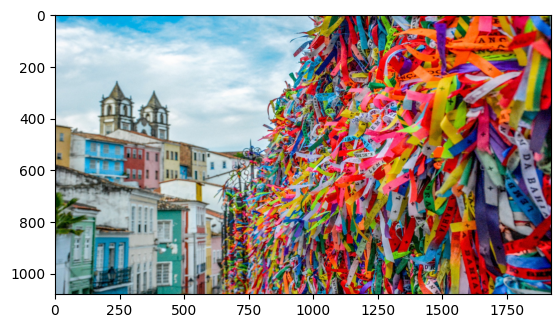

In [10]:
plt.imshow(image)

Com isso concluímos a parte prática da aula de hoje.

## Próximos Passos e Referências

Nas próximas aulas iremos aprender a trabalhar com mais bibliotecas utilizadas no dia a dia de profissionais de visão computacional.

Uma lista não exaustiva de referências segue:

- https://matplotlib.org/stable/
- https://matplotlib.org/stable/tutorials/images.html

## Atividades Complementares (Opicional)

- [ ] Leia a outra imagem do arquivo `rio.jpeg` e rode todos os comandos
- [ ] Altere o espaço de cores e veja como ficam as imagens.
- [ ] Podemos visualizar imagens que não foram lidas do disco utilizando `plt.imread`? Talvez criando vetores em `numpy`?

### Atividade 1 — Ler `rio.jpeg` e rodar todos os comandos

<class 'numpy.ndarray'>
shape: (2667, 4000, 3)
pixel [0,0]: [107 154 180]


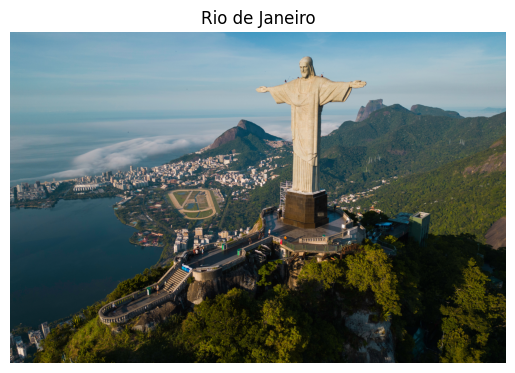

In [12]:

image_rio = plt.imread("../assets/rio.jpeg")

print(type(image_rio))
print("shape:", image_rio.shape)
print("pixel [0,0]:", image_rio[0, 0])

plt.imshow(image_rio)
plt.title("Rio de Janeiro")
plt.axis("off")
plt.show()

### Atividade 2 — Alterar o espaço de cores

`matplotlib` lê imagens em RGB. Para visualizar em outros espaços de cores, manipulamos os canais manualmente ou usamos `cmap` em `imshow`.

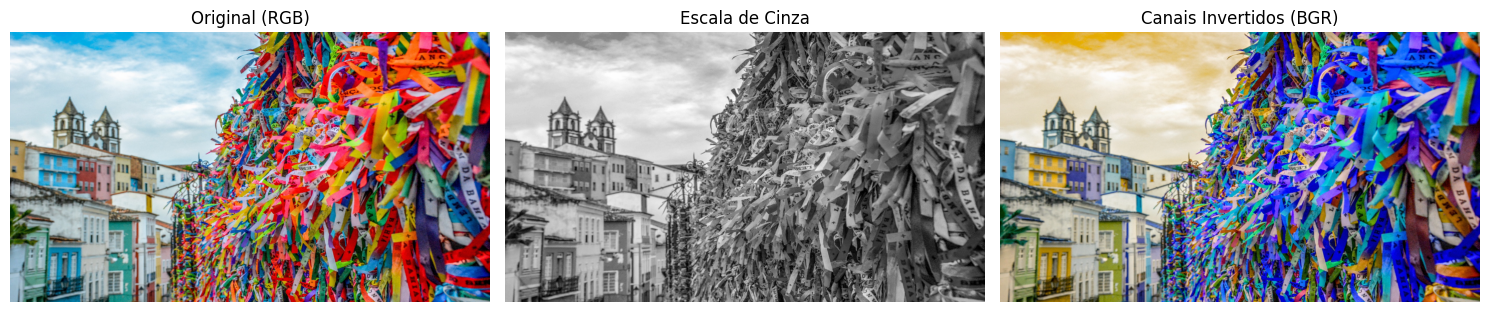

In [14]:
# Atividade 2: visualizar em diferentes espaços de cores
image_bahia = plt.imread("../assets/bahia.jpeg")

# Grayscale: média dos canais RGB (sem OpenCV, só numpy)
image_gray = image_bahia.mean(axis=2).astype(np.uint8)

# Inverte canais: RGB -> BGR (troca R e B)
image_bgr = image_bahia[:, :, ::-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_bahia)
axes[0].set_title("Original (RGB)")
axes[0].axis("off")

axes[1].imshow(image_gray, cmap="gray")
axes[1].set_title("Escala de Cinza")
axes[1].axis("off")

axes[2].imshow(image_bgr)
axes[2].set_title("Canais Invertidos (BGR)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Atividade 3 — Visualizar imagens criadas com NumPy (sem `plt.imread`)

`plt.imshow` aceita qualquer array NumPy com shape `(H, W)` ou `(H, W, 3)` — não precisa de `plt.imread`.

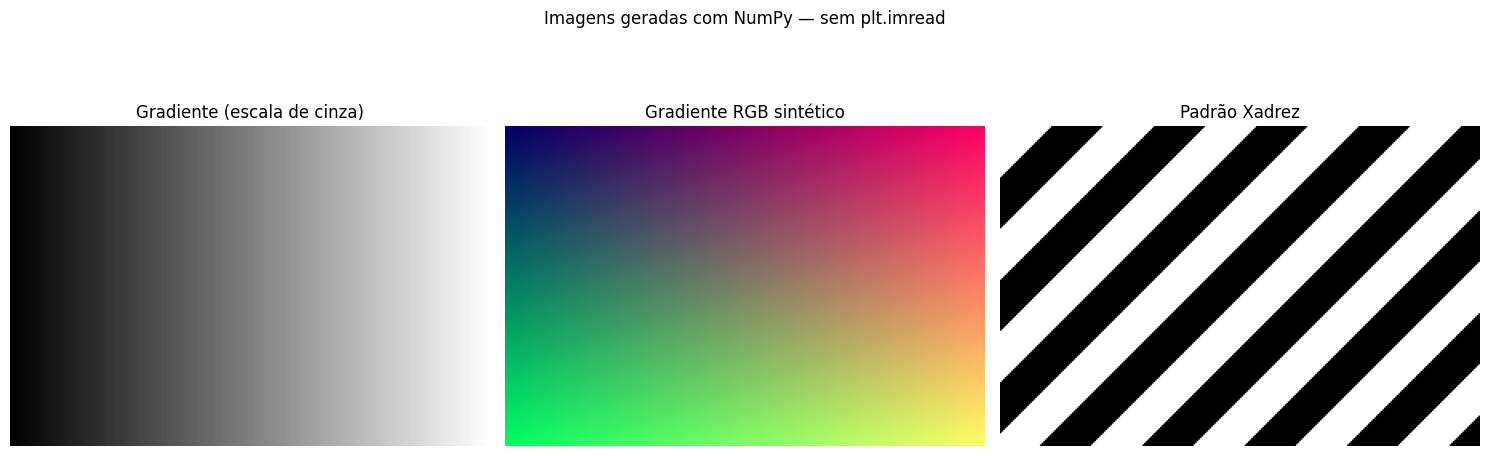

In [16]:
# Atividade 3: criar imagens com numpy e visualizar com plt.imshow

altura, largura = 200, 300

# Gradiente horizontal em escala de cinza
gradiente = np.tile(np.linspace(0, 255, largura, dtype=np.uint8), (altura, 1))

# Imagem RGB sintética: canal R aumenta da esquerda, G de cima, B constante
imagem_rgb = np.zeros((altura, largura, 3), dtype=np.uint8)
imagem_rgb[:, :, 0] = np.tile(np.linspace(0, 255, largura, dtype=np.uint8), (altura, 1))   # R
imagem_rgb[:, :, 1] = np.tile(np.linspace(0, 255, altura, dtype=np.uint8), (largura, 1)).T  # G
imagem_rgb[:, :, 2] = 100  # B fixo

# Padrão xadrez
xadrez = np.indices((altura, largura)).sum(axis=0) % 64 < 32
xadrez = (xadrez * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gradiente, cmap="gray")
axes[0].set_title("Gradiente (escala de cinza)")
axes[0].axis("off")

axes[1].imshow(imagem_rgb)
axes[1].set_title("Gradiente RGB sintético")
axes[1].axis("off")

axes[2].imshow(xadrez, cmap="gray")
axes[2].set_title("Padrão Xadrez")
axes[2].axis("off")

plt.suptitle("Imagens geradas com NumPy — sem plt.imread", y=1.02)
plt.tight_layout()
plt.show()